# Chest X-Ray Classification: ResNet50 — Dual Approach Comparison

**Pre-trained CNN Backbone:** ResNet50 (ImageNet weights)

- **Approach 1:** ResNet50 as a *fixed feature extractor* → features fed into an SVM classifier
- **Approach 2:** ResNet50 as a *complete end-to-end deep learning classifier* (fine-tuned)

## 0. Setup & Data Loading

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Dataset/chest_xray.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")

Done extracting!


In [23]:
train_dir = "/content/dataset/chest_xray/train"
test_dir  = "/content/dataset/chest_xray/test"

IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_CLASSES = 2

In [13]:
# ── Data generators ──────────────────────────────────────────────────────────
# ResNet50 expects inputs preprocessed with resnet50.preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Augmented generator — used for Approach-2 (end-to-end fine-tuning)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# No-augmentation generator — used for Approach-1 (feature extraction must be deterministic)
noaug_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# --- Approach-2 generators (augmented, shuffled) ---
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_data = noaug_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False          # must stay False for both approaches
)

# --- Approach-1 generator (no augmentation, no shuffle — deterministic) ---
train_data_noaug = noaug_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 5216 images belonging to 2 classes.


In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train_labels = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


## Shared Backbone: ResNet50 (ImageNet, no top)

Both approaches share the **same pre-trained ResNet50** backbone loaded once here.
- The convolutional base is kept **frozen** for feature extraction (Approach 1).
- It is later **partially unfrozen** for end-to-end fine-tuning (Approach 2).

In [15]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Load ResNet50 without the classification head
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze ALL layers — shared frozen state used by both approaches initially
for layer in base_model.layers:
    layer.trainable = False

print(f"ResNet50 loaded — {len(base_model.layers)} layers, all frozen.")
print(f"Output feature map shape: {base_model.output_shape}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 loaded — 175 layers, all frozen.
Output feature map shape: (None, 7, 7, 2048)


---
## Approach 1: ResNet50 as Fixed Feature Extractor → SVM Classifier

**Steps:**
1. Attach a `GlobalAveragePooling2D` to the frozen ResNet50 to obtain a 2048-D feature vector per image.
2. Run all training and test images through this extractor (no gradient updates).
3. Train an SVM (RBF kernel) on the extracted features.
4. Evaluate on the test set.

In [16]:
# ── Step 1: Build the feature extractor ──────────────────────────────────────
# Append GlobalAveragePooling2D to the frozen base → 2048-D vector
feature_extractor = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output),
    name="resnet50_feature_extractor"
)

print("Feature extractor output shape:", feature_extractor.output_shape)

Feature extractor output shape: (None, 2048)


In [17]:
# ── Step 2: Extract features from training and test images ───────────────────
import numpy as np

def extract_features(generator, extractor):
    """Pass all images through the frozen CNN and collect feature vectors."""
    features, labels = [], []
    for i in range(len(generator)):      # iterate over all batches
        x_batch, y_batch = generator[i]
        f = extractor.predict(x_batch, verbose=0)
        features.append(f)
        labels.append(y_batch)
    return np.vstack(features), np.argmax(np.vstack(labels), axis=1)

print("Extracting training features...")
X_train_feat, y_train_feat = extract_features(train_data_noaug, feature_extractor)

print("Extracting test features...")
test_data.reset()
X_test_feat, y_test_feat = extract_features(test_data, feature_extractor)

print(f"Train features: {X_train_feat.shape}, Test features: {X_test_feat.shape}")

Extracting training features...
Extracting test features...
Train features: (5216, 2048), Test features: (624, 2048)


In [18]:
# ── Step 3: Train SVM on extracted features ───────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Normalise features (important for RBF-SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled  = scaler.transform(X_test_feat)

# SVM with RBF kernel
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced'
)

print("Training SVM...")
svm.fit(X_train_scaled, y_train_feat)
print("Done.")

Training SVM...
Done.


In [19]:
# ── Step 4: Evaluate SVM ──────────────────────────────────────────────────────
y_pred_svm = svm.predict(X_test_scaled)
svm_acc = accuracy_score(y_test_feat, y_pred_svm)

print("=" * 50)
print("APPROACH 1 — ResNet50 Feature Extractor + SVM")
print("=" * 50)
print(f"SVM Accuracy: {svm_acc:.4f}")
print()
print(classification_report(y_test_feat, y_pred_svm))

APPROACH 1 — ResNet50 Feature Extractor + SVM
SVM Accuracy: 0.7804

              precision    recall  f1-score   support

           0       0.98      0.42      0.59       234
           1       0.74      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.71      0.72       624
weighted avg       0.83      0.78      0.75       624



---
## Approach 2: ResNet50 End-to-End Deep Learning Classifier

**The same ResNet50 backbone** is now used as the foundation of a full deep learning classifier.

**Training strategy (two phases):**
- **Phase 1 — Frozen base:** Train only the new classification head for 15 epochs to warm it up.
- **Phase 2 — Fine-tuning:** Unfreeze the top 60 ResNet50 layers and continue training with a lower learning rate.

In [24]:
# ── Build the end-to-end DL model ────────────────────────────────────────────
# Re-freeze all base layers first (in case Approach-1 mutated trainable flags)
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

for layer in base_model.layers:
    layer.trainable = False

# Add a custom classification head on top of the shared backbone
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

dl_model = Model(inputs=base_model.input, outputs=output, name="resnet50_end_to_end")

dl_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("End-to-end DL model built with 2 output nodes.")
dl_model.summary()

End-to-end DL model built with 2 output nodes.


Model: "resnet50_end_to_end"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,776,834 (94.52 MB)

 Trainable params: 1,185,026 (4.52 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [25]:
# ── Phase 1: Train head only (frozen backbone) — 15 epochs ──────────────────
print("Phase 1: Training classification head (backbone frozen)...")

history1 = dl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights
)

Phase 1: Training classification head (backbone frozen)...
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 140s 966ms/step - accuracy: 0.8342 - loss: 0.3847 - val_accuracy: 0.9022 - val_loss: 0.2355
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 843ms/step - accuracy: 0.9092 - loss: 0.2337 - val_accuracy: 0.9492 - val_loss: 0.1318
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 834ms/step - accuracy: 0.9269 - loss: 0.1925 - val_accuracy: 0.9444 - val_loss: 0.1268
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 111s 847ms/step - accuracy: 0.9372 - loss: 0.1557 - val_accuracy: 0.9415 - val_loss: 0.1376
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 113s 867ms/step - accuracy: 0.9379 - loss: 0.1603 - val_accuracy: 0.9511 - val_loss: 0.1353
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 843ms/step - accuracy: 0.9425 - loss: 0.1437 - val_accuracy: 0.9655 - val_loss: 0.0922
Epoch 7/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 845ms/step - accuracy: 0.9521 - loss: 0.1377 - val_accuracy: 0.9549 - val_loss: 0.0982
Epoch 8/15
131/13

In [26]:
# ── Phase 2: Fine-tune top 60 ResNet50 layers + head ─────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Unfreeze the top 60 layers of the ResNet50 backbone
for layer in base_model.layers[-60:]:
    layer.trainable = True

# Recompile with a lower learning rate for fine-tuning
dl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=4, verbose=1)
]

print("Phase 2: Fine-tuning top 60 layers of ResNet50 backbone...")

history2 = dl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=callbacks,
    class_weight=class_weights
)

Phase 2: Fine-tuning top 60 layers of ResNet50 backbone...
Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 161s 991ms/step - accuracy: 0.9482 - loss: 0.1368 - val_accuracy: 0.9626 - val_loss: 0.0901 - learning_rate: 1.0000e-05
Epoch 2/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 111s 847ms/step - accuracy: 0.9526 - loss: 0.1299 - val_accuracy: 0.9703 - val_loss: 0.0855 - learning_rate: 1.0000e-05
Epoch 3/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 112s 857ms/step - accuracy: 0.9593 - loss: 0.1032 - val_accuracy: 0.9703 - val_loss: 0.0832 - learning_rate: 1.0000e-05
Epoch 4/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 842ms/step - accuracy: 0.9650 - loss: 0.0861 - val_accuracy: 0.9693 - val_loss: 0.0792 - learning_rate: 1.0000e-05
Epoch 5/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 834ms/step - accuracy: 0.9657 - loss: 0.0962 - val_accuracy: 0.9722 - val_loss: 0.0815 - learning_rate: 1.0000e-05
Epoch 6/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 834ms/step - accuracy: 0.9665 - loss: 0.0883 - val_accuracy: 0.9760 - val_loss: 0.0705 - learnin

In [27]:
# ── Evaluate DL model ─────────────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

test_data.reset()
preds = dl_model.predict(test_data)
y_pred_dl = np.argmax(preds, axis=1)
y_true    = test_data.classes

dl_acc = accuracy_score(y_true, y_pred_dl)

print("=" * 50)
print("APPROACH 2 — ResNet50 End-to-End Deep Learning")
print("=" * 50)
print(f"DL Accuracy: {dl_acc:.4f}")
print()
print(classification_report(y_true, y_pred_dl))

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 472ms/step
APPROACH 2 — ResNet50 End-to-End Deep Learning
DL Accuracy: 0.9135

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       234
           1       0.93      0.93      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.91      0.91      0.91       624



---
## Final Comparison

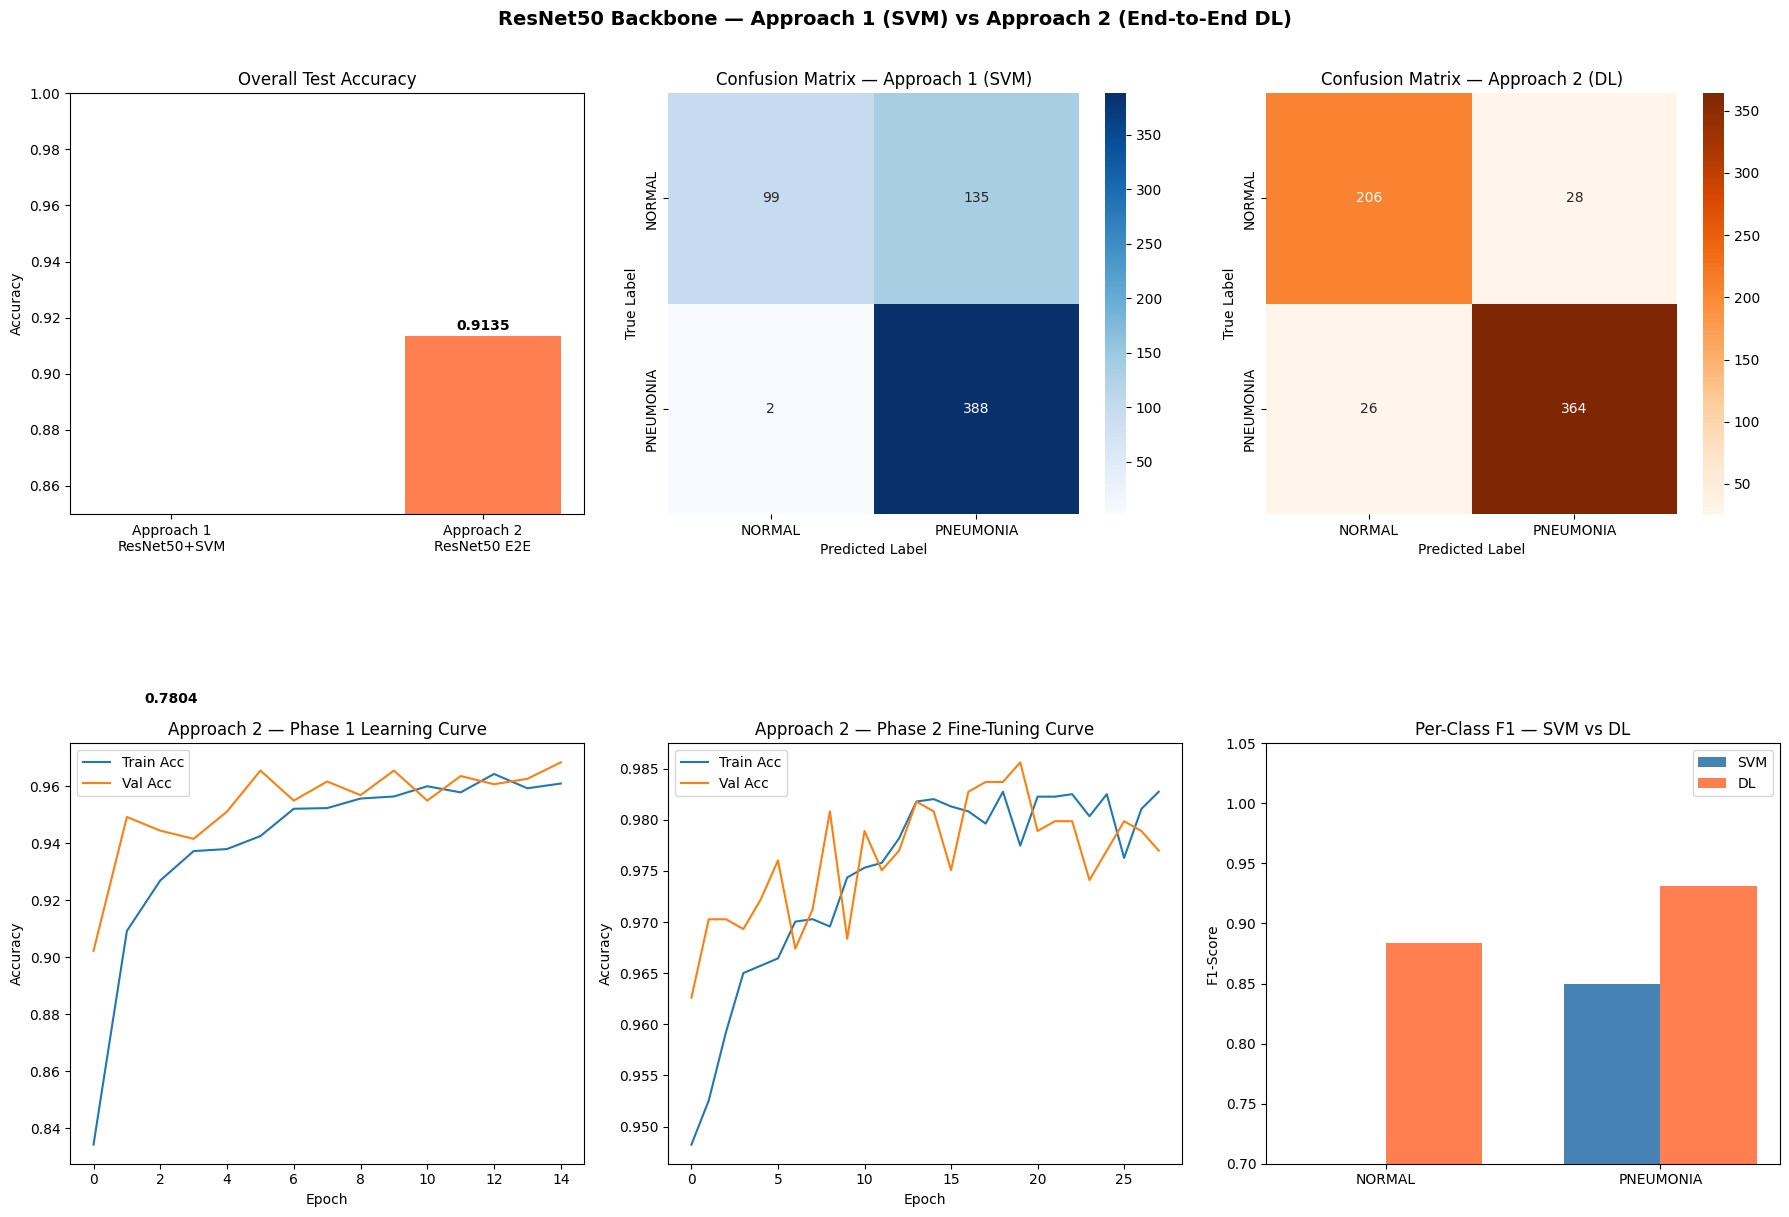


SUMMARY
Approach 1 — ResNet50 + SVM   Accuracy: 0.7804
Approach 2 — ResNet50 E2E DL  Accuracy: 0.9135
Best performer: Approach 2 (End-to-End DL)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = list(test_data.class_indices.keys())

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── Bar chart: overall accuracy ───────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
bars = ax0.bar(
    ['Approach 1\nResNet50+SVM', 'Approach 2\nResNet50 E2E'],
    [svm_acc, dl_acc],
    color=['steelblue', 'coral'],
    width=0.5
)
ax0.set_ylim(0.7, 1.0)
ax0.set_ylabel('Accuracy')
ax0.set_title('Overall Test Accuracy')
for bar, acc in zip(bars, [svm_acc, dl_acc]):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontweight='bold')

# ── Confusion matrix: SVM ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
cm_svm = confusion_matrix(y_test_feat, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix — Approach 1 (SVM)')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# ── Confusion matrix: DL ──────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
cm_dl = confusion_matrix(y_true, y_pred_dl)
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Confusion Matrix — Approach 2 (DL)')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# ── Learning curves: Phase 1 ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history1.history['accuracy'],     label='Train Acc')
ax3.plot(history1.history['val_accuracy'], label='Val Acc')
ax3.set_title('Approach 2 — Phase 1 Learning Curve')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.legend()

# ── Learning curves: Phase 2 ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(history2.history['accuracy'],     label='Train Acc')
ax4.plot(history2.history['val_accuracy'], label='Val Acc')
ax4.set_title('Approach 2 — Phase 2 Fine-Tuning Curve')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy')
ax4.legend()

# ── Per-class F1 comparison ───────────────────────────────────────────────────
from sklearn.metrics import f1_score

ax5 = fig.add_subplot(gs[1, 2])
f1_svm = f1_score(y_test_feat, y_pred_svm, average=None)
f1_dl  = f1_score(y_true,      y_pred_dl,  average=None)
x_pos  = np.arange(NUM_CLASSES)
w = 0.35
ax5.bar(x_pos - w/2, f1_svm, w, label='SVM',  color='steelblue')
ax5.bar(x_pos + w/2, f1_dl,  w, label='DL',   color='coral')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(class_names)
ax5.set_ylim(0.7, 1.05)
ax5.set_ylabel('F1-Score')
ax5.set_title('Per-Class F1 — SVM vs DL')
ax5.legend()

plt.suptitle('ResNet50 Backbone — Approach 1 (SVM) vs Approach 2 (End-to-End DL)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Approach 1 — ResNet50 + SVM   Accuracy: {svm_acc:.4f}")
print(f"Approach 2 — ResNet50 E2E DL  Accuracy: {dl_acc:.4f}")
winner = 'Approach 1 (SVM)' if svm_acc > dl_acc else 'Approach 2 (End-to-End DL)'
print(f"Best performer: {winner}")